In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv


In [5]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 使用遍历得到的准确路径
train = pd.read_csv("/kaggle/input/competitions/titanic/train.csv")
test = pd.read_csv("/kaggle/input/competitions/titanic/test.csv")
sub = pd.read_csv("/kaggle/input/competitions/titanic/gender_submission.csv")

print("训练集形状", train.shape)
print("测试集形状", test.shape)
display(train.head())

训练集形状 (891, 12)
测试集形状 (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
train.info()
train.describe()
print('训练集缺失情况：')
print(train.isnull().sum())
print('\n测试集缺失情况：')
print(test.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
训练集缺失情况：
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: 

Text(0.5, 1.0, 'Sex vs Survived')

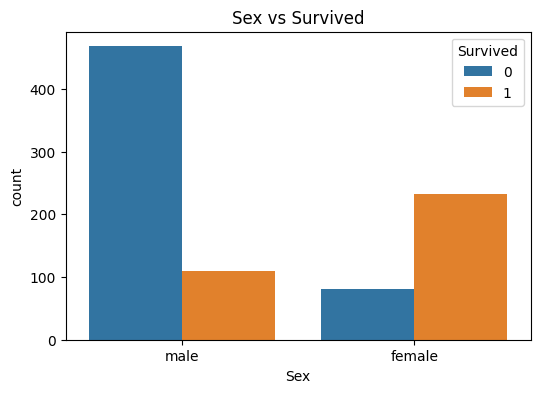

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x="Sex", hue="Survived", data=train)
plt.title("Sex vs Survived")

Text(0.5, 1.0, 'Pclass vs Survived')

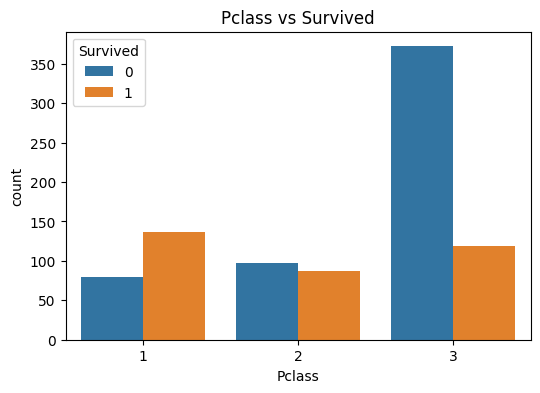

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x="Pclass", hue="Survived", data=train)
plt.title("Pclass vs Survived")

Text(0.5, 1.0, 'Age Distribution')

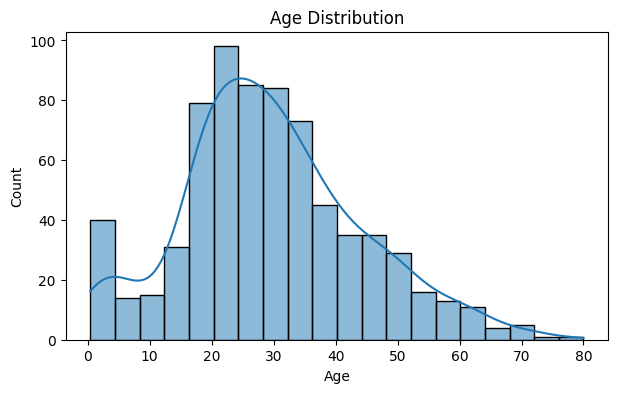

In [9]:
plt.figure(figsize=(7,4))
sns.histplot(train["Age"].dropna(), kde=True)
plt.title("Age Distribution")

In [12]:
all_data = pd.concat([train.drop("Survived", axis=1), test])

# 修改填充写法，去掉inplace=True规避警告
all_data["Age"] = all_data["Age"].fillna(all_data["Age"].median())
all_data["Embarked"] = all_data["Embarked"].fillna("S")
all_data["Fare"] = all_data["Fare"].fillna(all_data["Fare"].median())
all_data.drop("Cabin", axis=1, inplace=True)

# 剔除无用特征
drop_cols = ["PassengerId", "Name", "Ticket"]
all_data.drop(drop_cols, axis=1, inplace=True)

# 类别特征独热编码
all_data = pd.get_dummies(all_data, drop_first=True)

# 拆分训练、测试数据集
X_train = all_data.iloc[:len(train)]
X_test = all_data.iloc[len(train):]
y_train = train["Survived"]

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=500)
model.fit(X_tr, y_tr)
y_pred_val = model.predict(X_val)
print(f"本地验证准确率：{accuracy_score(y_val, y_pred_val):.4f}")

本地验证准确率：0.8101


In [14]:
test_pred = model.predict(X_test)
submit = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_pred.astype(int)
})
submit.to_csv("submission.csv", index=False)
print("提交文件submission.csv成功生成，可以前往右侧Output查看")

提交文件submission.csv成功生成，可以前往右侧Output查看


In [15]:
import pandas as pd
preview = pd.read_csv("/kaggle/working/submission.csv")
print('行列大小：', preview.shape)
print('\n前10行预览：')
print(preview.head(10))
print('\nSurvived所有不同取值：', preview['Survived'].unique())

行列大小： (418, 2)

前10行预览：
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0

Survived所有不同取值： [0 1]
